# How to Access the Giovanni Area-Average Time Series Service Using Python

### Date Authored: 04-19-2026

### Timing

Exercise: 5 minutes

### Overview

This notebook demonstrates how to access the Cloud-enabled Giovanni Area-Average Time Series Service using Python. It contains steps checking the user's Giovanni quota before proceeding with searching and querying the area-average time series service via the harmony-py library, with the end goal of finding the most intense dust storm over the Atlantic ocean since 2000 from the [MERRA-2 M2T1NXAER](https://www.earthdata.nasa.gov/data/catalog/ges-disc-m2t1nxaer-5.12.4) collection.

### Prerequisites

This notebook was written using Python 3.11, and requires:
- Valid [Earthdata Login credentials](https://urs.earthdata.nasa.gov), and the generation of [Earthdata Prerequisite Files](https://disc.gsfc.nasa.gov/information/howto?title=How%20to%20Generate%20Earthdata%20Prerequisite%20Files) including the <code>.netrc</code> file.
- [Xarray](https://docs.xarray.dev/en/stable/)
- [Rioxarray](https://corteva.github.io/rioxarray/html/index.html)
- [NumPy <v2](https://numpy.org/)
- [Harmony-py](https://harmony-py.readthedocs.io/en/main/)
- [Matplotlib](https://matplotlib.org/)
- [Cartopy](https://scitools.org.uk/cartopy/docs/latest/)

### Optional Anaconda Environment YAML:

This notebook can be run using the ['nasa-gesdisc' YAML file](https://github.com/nasa/gesdisc-tutorials/tree/main/environments/nasa-gesdisc.yml) provided in the 'environments' subfolder. 
Please follow the instructions [here](https://conda.io/projects/conda/en/latest/user-guide/tasks/manage-environments.html#creating-an-environment-from-an-environment-yml-file) to install and activate this environment.

### 1. Import Libraries

In [1]:
from harmony import Dimension, Client, Collection, Request, Environment, BBox
import datetime as dt
import os
import requests
import earthaccess
import xarray as xr
import rioxarray
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import cartopy.crs as ccrs

### 2. Create Client using Earthdata Login Credentials
This section will prompt the user for their Earthdata Login username and password and save them to a .netrc file if it does not already exist. An Earthdata account is always required to access NASA Earthdata or any subsetting services.

Then, a client object is created, and a bearer token will be extracted for querying the quota endpoint.

In [2]:
# Prompt for Earthdata Login credentials, store in a .netrc file if it does not exist
auth = earthaccess.login(strategy="interactive", persist=True)

# Create Harmony client
harmony_client = Client()

# Query and save token
token = earthaccess.get_edl_token()['access_token']

### 3. Query the Giovanni Quota Endpoint

Users are given a limited amount of compute quota per month to average the Giovanni area-averaged time service. This can be checked by using a token to query the following URL: https://api.giovanni.earthdata.nasa.gov/quota, which will return a float between 0 and 1 representing the fraction of compute quota used for that month.

In [3]:
# Set quota endpoint URL
quota_url = "https://api.giovanni.earthdata.nasa.gov/quota"

# Set up headers with the Bearer token
headers = {
    "Authorization": f"Bearer {token}",
    "Content-Type": "application/json"
}

# Make the GET request
response = requests.get(quota_url, headers=headers)

# Check the status of the response and quota fraction
print(response.status_code)
print(response.json())

200
{'status': 200, 'quota': 0}


### 4. Specify Collection and Spatiotemporal Subsetting Parameters

We will use the Dust Column Mass Density (DUCMASS) variable from the M2T1NXAER collection to calculate a long area-averaged time series over the Atlantic.

To find the specific enabled variable for this service, consult this JSON list of configured variables: https://api.giovanni.earthdata.nasa.gov/configured-variables/

In [4]:
# Enter collection short name
short_name = "M2T1NXAER"

# Enter collection version number as a string
version = "5.12.4"

# Enter Giovanni time series collection and variable string
variable = "M2T1NXAER_5_12_4_DUCMASS"

# Define the spatial bounding box to be averaged
bbox = BBox(-60.4687, -10.418, 12.6563, 37.3945)  # (west, south, east, north)

# Specify the start and end times in UTC
start = dt.datetime(2020, 1, 1, 0, 0, 0) # (year, month, day, hour, minute)
stop = dt.datetime(2025, 9, 1, 0, 0, 0)

### 5. Query the Giovanni Area-Averaged Time Series Service

This will download the time series in a CSV format.

In [5]:
# Query the CMR for the collection concept ID
concept_id = earthaccess.search_datasets(short_name=short_name, version=version)[0].concept_id()

collection = Collection(id=concept_id)
request = Request(
    collection=collection,
    temporal={"start": start, "stop": stop},
    spatial=bbox,
    variables=[variable],
    format="text/csv",
    average="area",
)

# Submit job and download results to a file
job_id = harmony_client.submit(request)
results = harmony_client.download_all(job_id)
for r in results:
    timeseries_fn = r.result()

179958020_GIOVANNI-areaAvgTimeSeries.M2T1NXAER_5_12_4_DUCMASS.20200101-20250901.60W_10S_12E_37N.csv


### 6. Parse the Output CSV File into a DataFrame

We need to parse header attributes in order to load the CSV into a Pandas DataFrame for analysis.

In [6]:
timeseries_attrs = {}
with open(timeseries_fn) as f:
    # Parse the header attributes until the line with just a comma
    done = False
    line = f.readline().strip()
    timeseries_attrs = {}
    while line != ",":
        attr, value = line.split(",", 1)
        timeseries_attrs[attr] = value
        line = f.readline().strip()
    # Parse the data
    timeseries_df = pd.read_csv(f, parse_dates=[0])

### 7. Plot Results

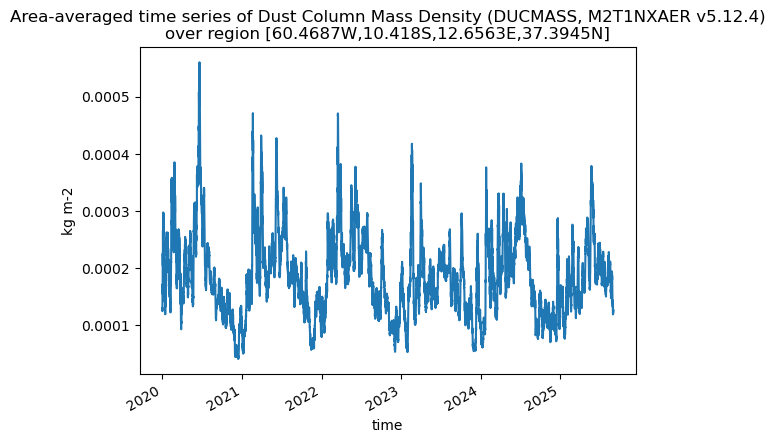

In [7]:
timeseries_df.plot(x="time",y="mean_M2T1NXAER_5_12_4_DUCMASS")
plt.ylabel("kg m-2")
ax = plt.gca()
ax.get_legend().remove()
plt.title("Area-averaged time series of Dust Column Mass Density (DUCMASS, M2T1NXAER v5.12.4)\nover region [60.4687W,10.418S,12.6563E,37.3945N]");